# Photophysics of Carborhodamines in H2O

In [2]:
#user = r"\SagixOffice"  # HomeOffice
user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import src.transitions as tr
import src.miscellaneous as mi
import src.fluorophores as fl
import src.statistics as st
import src.simulation as si
import src.emissions as em
import src.blinking as bl
import src.tcspc as tc
import src.fcs as fc
import matplotlib.pyplot as plt
import src.formulas as fo

import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2

C:\Users\vie43sq\Miniconda3\envs\MarkovModels\lib\site-packages\pycorrelate\pycorrelate.py:118: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def ucorrelate(t, u, maxlag=None):


In [3]:
fluorophore = fl.Fluorophore(name='atto643', position=[0, 0])

C:\Users\vie43sq\OneDrive - Universität Würzburg\GitHub\Photoswitching\src\fluorophores.py:43: UserWarning: Fluorophore atto643 not known. Parameters have to be defined manually.
  warnings.warn(f'Fluorophore {self.name} not known. Parameters have to be defined manually.')


In [4]:
fluorophore_system = fl.FluorophoreSystem([fluorophore])

## constants

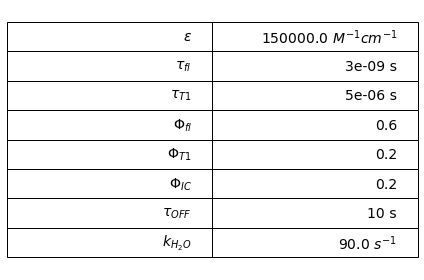

In [5]:
fluorescence_lifetime = 3e-9
triplet_lifetime = 5e-6
triplet_yield = 0.2
fluorescence_yield = 0.6
internal_conversion_yield = 0.2
extinction_coeff = 1.5e5
off_lifetime = 10
h2o_rate = 9e1

fig, ax = plt.subplots()

fig.patch.set_visible(False)
ax.axis('off')
ax.axis('tight')

table = ax.table(cellText=[[r'$\epsilon$', f'{extinction_coeff} ' + '$M^{-1}cm^{-1}$'],
                           [r'$\tau_{fl}$', f'{fluorescence_lifetime} s'],
                           [r'$\tau_{T1}$', f'{triplet_lifetime} s'],
                           [r'$\Phi_{fl}$', f'{fluorescence_yield}'],
                           [r'$\Phi_{T1}$', f'{triplet_yield}'], 
                           [r'$\Phi_{IC}$', f'{internal_conversion_yield}'],
                           [r'$\tau_{OFF}$', f'{off_lifetime} s'],
                           [r'$k_{H_{2}O}$', f'{h2o_rate} ' + '$s^{-1}$']], 
                 loc='center')
table.scale(1, 2)
table.set_fontsize(20)

fig.tight_layout()

plt.show()

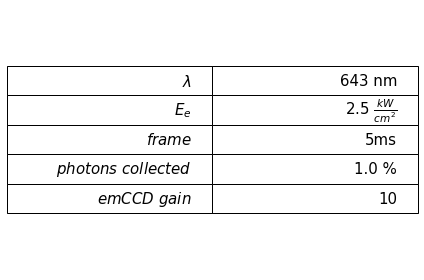

In [6]:
wavelength = 643
irradiance = 2.5 
frame = '5ms'
photon_collection_rate = 0.01
emccd_gain = 10

fig, ax = plt.subplots()

fig.patch.set_visible(False)
ax.axis('off')
ax.axis('tight')

table = ax.table(cellText=[[r'$\lambda$', f'{wavelength} nm'],
                           [r'$E_{e}$', f'{irradiance} ' + r'$\frac{kW}{cm^{2}}$'],
                           [r'$frame$', frame],
                           [r'$photons \ collected$', f'{photon_collection_rate * 100} %'],
                           [r'$emCCD \ gain$', f'{emccd_gain}']], 
                 loc='center')
table.scale(1, 2)
table.set_fontsize(20)

fig.tight_layout()

plt.show()

In [7]:
wavenumber, wavelength, frequency = fo.convert_wavenumber_wavelength_frequency(wavelength=wavelength)
photon_flux = fo.calculate_photon_flux(irradiance=irradiance, frequency=frequency)
excitation_rate = fo.calculate_excitation_rate(photon_flux=photon_flux, extinction_coefficient=extinction_coeff)
emission_rate = fo.calculate_emission_rate(quantum_yield=fluorescence_yield, fluorescence_lifetime=fluorescence_lifetime)
isc_st_rate = fo.calculate_emission_rate(quantum_yield=triplet_yield, fluorescence_lifetime=fluorescence_lifetime)
isc_ts_rate = 1/triplet_lifetime
internal_conversion_rate = fo.calculate_emission_rate(quantum_yield=internal_conversion_yield, fluorescence_lifetime=fluorescence_lifetime)

In [8]:
excitation = tr.Transition(tr.TransitionType.EXCITATION, excitation_rate)
emission = tr.Transition(tr.TransitionType.FLUORESCENT_EMISSION, emission_rate)
isc_st = tr.Transition(tr.TransitionType.INTERSYSTEM_CROSSING_ST, isc_st_rate)
isc_ts = tr.Transition(tr.TransitionType.INTERSYSTEM_CROSSING_TS, isc_ts_rate)
internal_conversion = tr.Transition(tr.TransitionType.INTERNAL_CONVERSION_S, internal_conversion_rate)
h2o_attack = tr.Transition(tr.TransitionType.H2O_ATTACK_T, h2o_rate)
back_reaction = tr.Transition(tr.TransitionType.BACK_REACTION, 1/off_lifetime)

transitions = [excitation, emission, internal_conversion, isc_st, isc_ts, h2o_attack, back_reaction]

In [9]:
transition_set = tr.TransitionSet(transitions, fluorophore_system)

In [10]:
transition_set.finalize()

<AxesSubplot:>

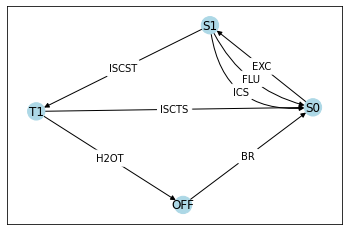

In [11]:
transition_set.plot('kamadar')

In [12]:
transition_set.transition_df

,transition_type,abbreviation,initial_state,final_state,rate,photon,energy_transfer,distance
id,,,,,,,,
0,TransitionType.EXCITATION,EXC,SingleState.S0,SingleState.S1,4.641200e+06,False,False,None
1,TransitionType.FLUORESCENT_EMISSION,FLU,SingleState.S1,SingleState.S0,2.000000e+08,True,False,None
2,TransitionType.INTERNAL_CONVERSION_S,ICS,SingleState.S1,SingleState.S0,6.666667e+07,False,False,None
3,TransitionType.INTERSYSTEM_CROSSING_ST,ISCST,SingleState.S1,SingleState.T1,6.666667e+07,False,False,None
4,TransitionType.INTERSYSTEM_CROSSING_TS,ISCTS,SingleState.T1,SingleState.S0,2.000000e+05,False,False,None
5,TransitionType.H2O_ATTACK_T,H2OT,SingleState.T1,SingleState.OFF,9.000000e+01,False,False,None
6,TransitionType.BACK_REACTION,BR,SingleState.OFF,SingleState.S0,1.000000e-01,False,False,None


In [13]:
simulation = si.Simulation(transition_set)
simulation.run(size=int(1e8), end_time=None, use_memmap=None, seed=3)
analysis = st.Analysis(simulation)

In [14]:
emissions = em.Emissions(simulation, photon_collection_rate=photon_collection_rate, resample=frame, emccd_gain=emccd_gain, 
                         seed=100)
fcs = fc.FCS(emissions).autocorrelate_time_points(exp_min=-8, exp_max=1)
blinking = bl.Blinking(emissions)

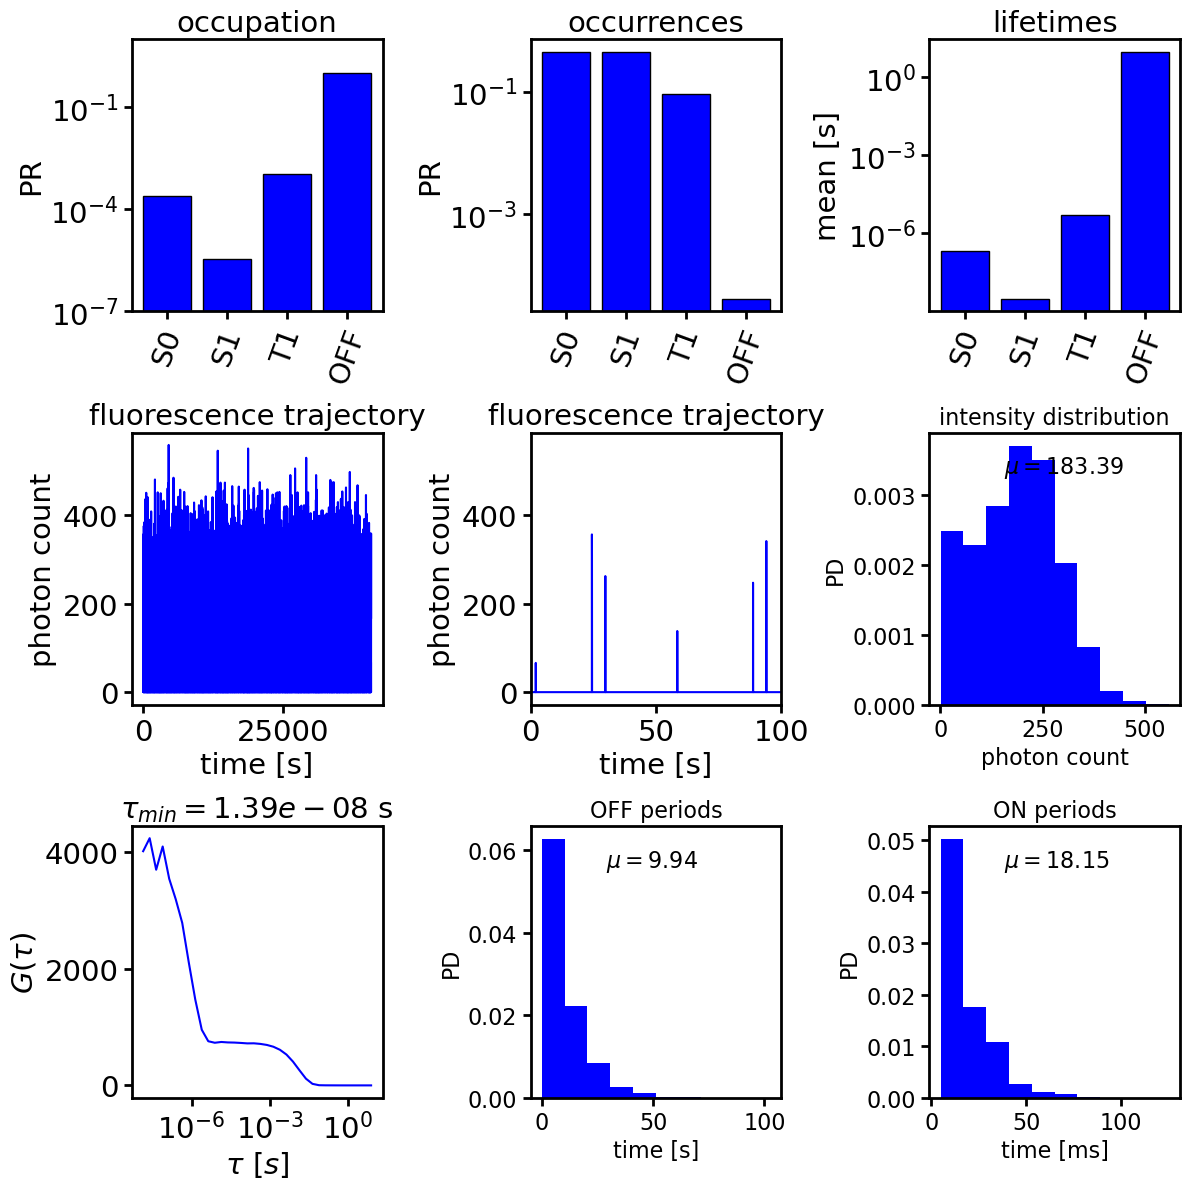

In [19]:
axes = analysis.plot(nrows=3, ncols=3, fig_height=12, fig_width=12, mode='state_occupations', ylim=[1e-7, 1e1])
analysis.plot(axes=axes[0, 1], mode='state_occurrences')
analysis.plot(axes=axes[0, 2], mode='mean_lifetimes')
emissions.plot(axes=axes[1, 0], mode='time_series')
emissions.plot(axes=axes[1, 1], mode='time_series', xlim=[0, 100])
emissions.plot(axes=axes[1, 2], mode='histogram', display_mean=True)
fcs.plot(axes=axes[2, 0], xticks=[1e-6, 1e-3, 1e0])
blinking.plot(axes=axes[2, 1], mode='off_histogram', as_time='s')
blinking.plot(axes=axes[2, 2], mode='on_histogram', as_time='ms')

axes[0, 0].get_figure().tight_layout()

In [ ]:
analysis.state_occupations

array([2.40335074e-04, 3.34573016e-06, 1.11492577e-03, 9.98641393e-01])

In [22]:
analysis.state_occurrences

array([4.54537225e-01, 4.54537225e-01, 9.08840391e-02, 4.15099996e-05])

In [23]:
analysis.mean_lifetimes

array([2.15455116e-07, 2.99937362e-09, 4.99881996e-06, 9.80315676e+00])

In [32]:
sec_per_frame = emissions.event_time_series.index[1] - emissions.event_time_series.index[0]

In [33]:
blinking.on_periods.mean() * sec_per_frame * 1000

18.148510014655596

In [34]:
blinking.off_periods.mean() * sec_per_frame

9.935014655593552

In [36]:
events = emissions.event_time_series
events = events[events != 0]
events.mean()

183.39137455426226

In [37]:
ref_state_occupations = np.array([2.40335074e-04, 3.34573016e-06, 1.11492577e-03, 9.98641393e-01])
ref_state_occurrences = np.array([4.54537225e-01, 4.54537225e-01, 9.08840391e-02, 4.15099996e-05])
ref_mean_lifetimes = np.array([2.15455116e-07, 2.99937362e-09, 4.99881996e-06, 9.80315676e+00])
ref_mean_on_periods = 18.148510014655596
ref_mean_off_periods = 9.935014655593552
ref_mean_intensity = 183.39137455426226